In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,classification_report

In [67]:
df = pd.read_csv("../../data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [80]:
df['target'].value_counts()
df = df.drop_duplicates()

In [81]:
df.shape

(302, 14)

In [ ]:
X = df[['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach',
       'exang', 'thal']]

y = df['target']


In [106]:
rf = RandomForestClassifier(n_estimators=200,max_depth=8,random_state=42)
xg = XGBClassifier(random_state = 42,
    eval_metric = "logloss",
    use_label_encoder = False)

In [107]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [108]:
rf.fit(X_train,y_train)
xg.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
y_pred_xg = xg.predict(X_test)
rf_accuracy = accuracy_score(y_test,y_pred_rf)
xg_accuracy = accuracy_score(y_test,y_pred_xg)
print("Rf accuracy", rf_accuracy)
print("xg accuracy", xg_accuracy)

Rf accuracy 0.7540983606557377
xg accuracy 0.7213114754098361


c:\Users\chinm\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:30:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [109]:

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

Train Accuracy: 1.0
Test Accuracy: 0.7540983606557377


In [110]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print(scores)
print("Mean Accuracy:", scores.mean())

[0.83606557 0.78688525 0.85       0.75       0.73333333]
Mean Accuracy: 0.7912568306010929


In [111]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)
feature_importance

,feature,importance
5,thalach,0.191346
2,cp,0.169762
7,thal,0.150433
0,age,0.135714
4,chol,0.120916
3,trestbps,0.103549
6,exang,0.064700
1,sex,0.063579


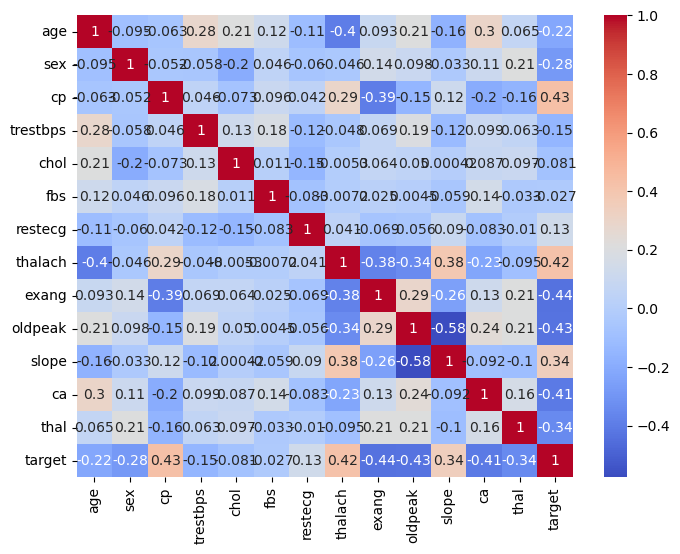

In [112]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [113]:
print(df["thal"].unique())

[3 2 1 0]


In [114]:
from sklearn.model_selection import RandomizedSearchCV

In [115]:
param_dist_rf = {
    "n_estimators": np.arange(100, 500, 50),
    "max_depth": [None, 4, 6, 8, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

param_dist_xgb = {
    "n_estimators": np.arange(100, 400, 50),
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3]
}

In [116]:
rf = RandomForestClassifier(class_weight='balanced',random_state=42)
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

In [117]:
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=20,              # number of combinations to try
    cv=5,                   # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 4, 6, 8, 10],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': array([100, 150, 200, 250, 300, 350, 400, 450])},
                   random_state=42, verbose=2)

In [118]:
print("Best Params:", rf_random.best_params_)
print("Best Score:", rf_random.best_score_)

best_rf = rf_random.best_estimator_

Best Params: {'n_estimators': np.int64(200), 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}
Best Score: 0.7925170068027211


In [ ]:
rf_pred = best_rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

RF Accuracy: 0.7868852459016393
              precision    recall  f1-score   support

           0       0.85      0.72      0.78        32
           1       0.74      0.86      0.79        29

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61

